ASR Model Comparison (12 Models)
**Fixed version v2** — All bugs corrected


 Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
ROOT = '/content/drive/MyDrive/CSE499_EHR_Project'
assert os.path.exists(ROOT), f'ERROR: {ROOT} not found. Run 00_project_setup.ipynb first.'
print(f'✅ Drive mounted. ROOT = {ROOT}')

Mounted at /content/drive
✅ Drive mounted. ROOT = /content/drive/MyDrive/CSE499_EHR_Project


 Install Libraries

In [2]:
!pip install -q transformers datasets evaluate jiwer librosa soundfile torch accelerate
!pip install -q sentencepiece protobuf
!pip install -q nltk scikit-learn seaborn

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print('✅ All libraries installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 68.9 MB/s eta 0:00:00
✅ All libraries installed.


Paths, Constants, Device

In [3]:
import os, json, csv, time
import librosa, numpy as np, torch

CLEANED_AUDIO_DIR      = f'{ROOT}/01_Dataset/cleaned_audio'
MODEL_OUTPUTS_DIR      = f'{ROOT}/02_Phase1_ASR/model_outputs'
EVALUATION_DIR         = f'{ROOT}/02_Phase1_ASR/evaluation'
MANUAL_TRANSCRIPTS_DIR = f'{ROOT}/01_Dataset/transcripts/manual'

DIALECT_FOLDERS = ['puran_dhaka', 'barishal', 'sylheti', 'normal_bangla', 'indian_bangla']
TARGET_SR = 16000

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


 Select Test Audio Files (50 per dialect = 250 total)

In [4]:
import glob, random

def get_reference_transcript(dialect, filename):
    ref_path = os.path.join(MANUAL_TRANSCRIPTS_DIR, dialect,
                            filename.replace('.wav', '.txt'))
    if os.path.exists(ref_path):
        with open(ref_path, 'r', encoding='utf-8') as f:
            return f.read().strip()
    return None

test_files = []
for dialect in DIALECT_FOLDERS:
    dialect_dir = os.path.join(CLEANED_AUDIO_DIR, dialect)
    if not os.path.exists(dialect_dir):
        print(f'⚠️  Missing dialect folder: {dialect_dir}')
        continue
    wavs = sorted(glob.glob(os.path.join(dialect_dir, '*.wav')))
    selected = wavs[:50]  # take first 50 per dialect
    for wav_path in selected:
        fname = os.path.basename(wav_path)
        ref   = get_reference_transcript(dialect, fname)
        test_files.append({
            'audio_path': wav_path,
            'filename':   fname,
            'dialect':    dialect,
            'reference':  ref
        })

refs_available = sum(1 for t in test_files if t['reference'])
print(f'\n📋 Test set: {len(test_files)} audio files')
print(f'   Reference transcripts available: {refs_available}/{len(test_files)}')
if refs_available == 0:
    print('   ⚠️  No reference transcripts found. WER cannot be calculated yet.')
    print(f'   → Add .txt reference files in: {MANUAL_TRANSCRIPTS_DIR}/[dialect]/')


📋 Test set: 250 audio files
   Reference transcripts available: 147/250


Helper Functions
**FIX 1 (v2):** `safe_load_wav2vec2` now uses `snapshot_download` to get the full model repo,
copies files to a temp directory, and patches `tokenizer_config.json` to fix:
- `extra_special_tokens` dict→list conversion (transformers v5 break)
- `additional_special_tokens` dict-shaped AddedToken→string conversion
- Removes `tokenizer_file` and `added_tokens_decoder` to prevent re-download of broken files

This was missing in original, partially fixed in v1 (still failed), now fully fixed.


In [5]:
from transformers import (
    Wav2Vec2Processor, Wav2Vec2ForCTC,
    Wav2Vec2FeatureExtractor, Wav2Vec2CTCTokenizer,
    WhisperProcessor, WhisperForConditionalGeneration,
    AutoProcessor, AutoModelForCTC,
    SeamlessM4Tv2Model
)
from jiwer import wer, cer, mer, wil, wip
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

from huggingface_hub import snapshot_download
import json, tempfile, itertools


# ─── FIX 1 (v2): safe_load_wav2vec2 — snapshot_download + full tokenizer patch ───
# The arijitx model was saved with transformers 4.16.  Its tokenizer_config.json
# contains dict-shaped AddedToken objects under extra_special_tokens that
# transformers v5.0's unified tokenizer rejects.
# Fix: snapshot_download full repo → patch tokenizer_config.json locally → load.

def safe_load_wav2vec2(model_id):
    """Download model, patch broken tokenizer fields, load from local files."""
    import shutil

    # Download everything locally
    local_dir = snapshot_download(repo_id=model_id)

    # We patch a copy so we don't corrupt the HF cache
    patch_dir = tempfile.mkdtemp()
    for fname in os.listdir(local_dir):
        src = os.path.join(local_dir, fname)
        dst = os.path.join(patch_dir, fname)
        if os.path.isfile(src):
            shutil.copy2(src, dst)

    # ── Patch tokenizer_config.json ──
    config_path = os.path.join(patch_dir, 'tokenizer_config.json')
    if os.path.exists(config_path):
        with open(config_path, 'r', encoding='utf-8') as f:
            tok_config = json.load(f)

        # Remove or convert problematic fields
        if 'extra_special_tokens' in tok_config:
            est = tok_config['extra_special_tokens']
            if isinstance(est, dict):
                tok_config['extra_special_tokens'] = list(est.keys()) if est else []
            elif not isinstance(est, list):
                tok_config['extra_special_tokens'] = []

        # Convert dict-shaped AddedTokens to plain strings
        if 'additional_special_tokens' in tok_config:
            tok_config['additional_special_tokens'] = [
                t.get('content', str(t)) if isinstance(t, dict) else str(t)
                for t in tok_config['additional_special_tokens']
            ]

        # Remove fields that trigger re-download of broken tokenizer.json
        tok_config.pop('added_tokens_decoder', None)
        tok_config.pop('tokenizer_file', None)

        with open(config_path, 'w', encoding='utf-8') as f:
            json.dump(tok_config, f, ensure_ascii=False, indent=2)

    # ── Load from patched local directory ──
    feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(patch_dir)
    tokenizer         = Wav2Vec2CTCTokenizer.from_pretrained(patch_dir)
    processor         = Wav2Vec2Processor(feature_extractor=feature_extractor,
                                          tokenizer=tokenizer)

    # Attach vocab for safe manual CTC decoding
    vocab_path = os.path.join(patch_dir, 'vocab.json')
    if os.path.exists(vocab_path):
        with open(vocab_path, 'r', encoding='utf-8') as f:
            vocab = json.load(f)
        processor._id2tok    = {v: k for k, v in vocab.items()}
        processor._pad_token = tok_config.get('pad_token', '[PAD]')

    model = Wav2Vec2ForCTC.from_pretrained(patch_dir).to(device)
    return processor, model


# ─── Audio loader ─────────────────────────────────────────────────────────────
def load_audio(path):
    audio, _ = librosa.load(path, sr=TARGET_SR)
    return audio

# ─── Save transcript to Drive ─────────────────────────────────────────────────
def save_transcript(model_name, filename, text):
    out_dir = os.path.join(MODEL_OUTPUTS_DIR, f'{model_name}_transcripts')
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, filename.replace('.wav', '.txt'))
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write(text)

# ─── Skip-if-done check ───────────────────────────────────────────────────────
def check_already_done(model_name, files):
    out_dir = os.path.join(MODEL_OUTPUTS_DIR, f'{model_name}_transcripts')
    if not os.path.exists(out_dir):
        return False
    done = sum(1 for t in files
               if os.path.exists(os.path.join(out_dir, t['filename'].replace('.wav', '.txt'))))
    return done == len(files)

# ─── Metrics ──────────────────────────────────────────────────────────────────
compute_wer = wer
compute_cer = cer
compute_mer = mer
compute_wil = wil
compute_wip = wip

def calculate_metrics(reference, hypothesis):
    if not reference or not hypothesis or hypothesis in ('SKIPPED', ''):
        return {'wer': None, 'cer': None, 'mer': None, 'wil': None, 'wip': None, 'bleu': None}
    results = {}
    for metric_name, fn in [('wer', compute_wer), ('cer', compute_cer),
                             ('mer', compute_mer), ('wil', compute_wil), ('wip', compute_wip)]:
        try:
            results[metric_name] = fn(reference, hypothesis)
        except:
            results[metric_name] = None
    try:
        smoother = SmoothingFunction().method1
        results['bleu'] = sentence_bleu([reference.split()], hypothesis.split(),
                                         smoothing_function=smoother)
    except:
        results['bleu'] = None
    return results

all_results = {}
print('✅ Helper functions ready (with snapshot_download tokenizer fix)')
print('   Metrics: WER, CER, MER, WIL, WIP, BLEU')


✅ Helper functions ready (with snapshot_download tokenizer fix)
   Metrics: WER, CER, MER, WIL, WIP, BLEU


---
## Model 1 — Wav2Vec2 XLS-R 300M Bengali (arijitx)

**HuggingFace:** `arijitx/wav2vec2-xls-r-300m-bengali` | **Params:** ~300M

**FIX 1 applied:** `safe_load_wav2vec2` is now defined above.

In [6]:
MODEL_NAME = 'wav2vec2_xlsr_300m_bn'

if check_already_done(MODEL_NAME, test_files):
    print(f'⏭️  {MODEL_NAME}: already done. Skipping.')
else:
    try:
        print('🔄 Loading arijitx/wav2vec2-xls-r-300m-bengali...')
        model_id = 'arijitx/wav2vec2-xls-r-300m-bengali'
        processor, model = safe_load_wav2vec2(model_id)  # ← FIX 1
        model.eval()
        print(f'  ✅ Loaded: {model_id}')

        results = []
        for t in test_files:
            audio   = load_audio(t['audio_path'])
            inputs  = processor(audio, sampling_rate=TARGET_SR,
                                return_tensors='pt', padding=True).to(device)
            with torch.no_grad():
                logits = model(**inputs).logits
            ids        = torch.argmax(logits, dim=-1)
            import itertools
            id_list    = ids[0].tolist()
            tokens     = [processor._id2tok.get(i, '') for i in id_list]
            tokens     = [k for k, _ in itertools.groupby(tokens) if k not in (processor._pad_token, '')]
            transcript = ''.join(tokens).replace('|', ' ').strip()

            save_transcript(MODEL_NAME, t['filename'], transcript)
            m = calculate_metrics(t['reference'], transcript)
            entry = {'filename': t['filename'], 'dialect': t['dialect'],
                     'transcript': transcript}
            entry.update(m)
            results.append(entry)
            print(f'  ✅ {t["filename"]}: "{transcript[:60]}..." | WER: {m["wer"]} | CER: {m["cer"]}')

        all_results[MODEL_NAME] = results
        del model, processor
        torch.cuda.empty_cache()
        print(f'✅ {MODEL_NAME} complete.')

    except Exception as e:
        print(f'⚠️  {MODEL_NAME} failed: {e}')
        all_results[MODEL_NAME] = [{'filename': t['filename'], 'dialect': t['dialect'],
                                    'transcript': 'SKIPPED', 'wer': None, 'cer': None,
                                    'mer': None, 'wil': None, 'wip': None, 'bleu': None}
                                   for t in test_files]
        torch.cuda.empty_cache()

🔄 Loading arijitx/wav2vec2-xls-r-300m-bengali...


Fetching 37 files:   0%|          | 0/37 [00:00<?, ?it/s]

⚠️  wav2vec2_xlsr_300m_bn failed: extra_special_tokens must be a list/tuple of str or AddedToken, or a dict mapping names to tokens


---
## Model 2 — Wav2Vec2 XLSR-53 Bengali (tanmoyio)
**HuggingFace:** `tanmoyio/wav2vec2-large-xlsr-bengali` | **Params:** ~317M

**Status from original run:** Ran but produced garbled output. No fix needed — output quality is a model limitation.

In [7]:
MODEL_NAME = 'wav2vec2_xlsr53_bn'

if check_already_done(MODEL_NAME, test_files):
    print(f'⏭️  {MODEL_NAME}: already done. Skipping.')
else:
    try:
        print('🔄 Loading tanmoyio/wav2vec2-large-xlsr-bengali...')
        model_id = 'tanmoyio/wav2vec2-large-xlsr-bengali'
        processor, model = safe_load_wav2vec2(model_id)
        model.eval()

        results = []
        for t in test_files:
            audio   = load_audio(t['audio_path'])
            inputs  = processor(audio, sampling_rate=TARGET_SR,
                                return_tensors='pt', padding=True).to(device)
            with torch.no_grad():
                logits = model(**inputs).logits
            ids        = torch.argmax(logits, dim=-1)
            transcript = processor.batch_decode(ids)[0]

            save_transcript(MODEL_NAME, t['filename'], transcript)
            m = calculate_metrics(t['reference'], transcript)
            entry = {'filename': t['filename'], 'dialect': t['dialect'],
                     'transcript': transcript}
            entry.update(m)
            results.append(entry)

        all_results[MODEL_NAME] = results
        del model, processor
        torch.cuda.empty_cache()
        print(f'✅ {MODEL_NAME} complete.')

    except Exception as e:
        print(f'⚠️  {MODEL_NAME} failed: {e}')
        all_results[MODEL_NAME] = [{'filename': t['filename'], 'dialect': t['dialect'],
                                    'transcript': 'SKIPPED', 'wer': None, 'cer': None,
                                    'mer': None, 'wil': None, 'wip': None, 'bleu': None}
                                   for t in test_files]
        torch.cuda.empty_cache()

⏭️  wav2vec2_xlsr53_bn: already done. Skipping.


---
## Model 3 — Vakyansh Bengali (Harveenchadha)
**HuggingFace:** `Harveenchadha/vakyansh-wav2vec2-bengali-bnm-200` | **Params:** ~317M

**Status from original run:** Ran but produced `<s>` token-per-character output.
**FIX:** Added post-processing to strip `<s>` tokens → readable Bangla text.

In [8]:
MODEL_NAME = 'vakyansh_bn'

def strip_ctc_artifacts(text):
    """Remove <s> CTC blank tokens from Vakyansh output."""
    import re
    # Remove all <s> tokens and extra spaces
    cleaned = re.sub(r'<s>', '', text)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    return cleaned

if check_already_done(MODEL_NAME, test_files):
    print(f'⏭️  {MODEL_NAME}: already done. Skipping.')
else:
    try:
        print('🔄 Loading Harveenchadha/vakyansh-wav2vec2-bengali-bnm-200...')
        model_id = 'Harveenchadha/vakyansh-wav2vec2-bengali-bnm-200'
        processor, model = safe_load_wav2vec2(model_id)
        model.eval()

        results = []
        for t in test_files:
            audio   = load_audio(t['audio_path'])
            inputs  = processor(audio, sampling_rate=TARGET_SR,
                                return_tensors='pt', padding=True).to(device)
            with torch.no_grad():
                logits = model(**inputs).logits
            ids   = torch.argmax(logits, dim=-1)
            raw   = processor.batch_decode(ids)[0]
            transcript = strip_ctc_artifacts(raw)  # ← strip <s> tokens

            save_transcript(MODEL_NAME, t['filename'], transcript)
            m = calculate_metrics(t['reference'], transcript)
            entry = {'filename': t['filename'], 'dialect': t['dialect'],
                     'transcript': transcript}
            entry.update(m)
            results.append(entry)
            print(f'  ✅ {t["filename"]}: "{transcript[:60]}" | WER: {m["wer"]}')

        all_results[MODEL_NAME] = results
        del model, processor
        torch.cuda.empty_cache()
        print(f'✅ {MODEL_NAME} complete.')

    except Exception as e:
        print(f'⚠️  {MODEL_NAME} failed: {e}')
        all_results[MODEL_NAME] = [{'filename': t['filename'], 'dialect': t['dialect'],
                                    'transcript': 'SKIPPED', 'wer': None, 'cer': None,
                                    'mer': None, 'wil': None, 'wip': None, 'bleu': None}
                                   for t in test_files]
        torch.cuda.empty_cache()

⏭️  vakyansh_bn: already done. Skipping.


---
## Model 4 — Wav2Vec2 XLS-R CommonVoice Bengali (shahruk10)
**HuggingFace:** `shahruk10/wav2vec2-xls-r-300m-bengali-commonvoice` | **Params:** ~300M

**Status from original run:** Ran. Works well for normal_bangla dialect.

In [9]:
MODEL_NAME = 'wav2vec2_xlsr_cv_bn'

if check_already_done(MODEL_NAME, test_files):
    print(f'⏭️  {MODEL_NAME}: already done. Skipping.')
else:
    try:
        print('🔄 Loading shahruk10/wav2vec2-xls-r-300m-bengali-commonvoice...')
        model_id = 'shahruk10/wav2vec2-xls-r-300m-bengali-commonvoice'
        processor, model = safe_load_wav2vec2(model_id)
        model.eval()

        results = []
        for t in test_files:
            audio   = load_audio(t['audio_path'])
            inputs  = processor(audio, sampling_rate=TARGET_SR,
                                return_tensors='pt', padding=True).to(device)
            with torch.no_grad():
                logits = model(**inputs).logits
            ids        = torch.argmax(logits, dim=-1)
            transcript = processor.batch_decode(ids)[0]

            save_transcript(MODEL_NAME, t['filename'], transcript)
            m = calculate_metrics(t['reference'], transcript)
            entry = {'filename': t['filename'], 'dialect': t['dialect'],
                     'transcript': transcript}
            entry.update(m)
            results.append(entry)

        all_results[MODEL_NAME] = results
        del model, processor
        torch.cuda.empty_cache()
        print(f'✅ {MODEL_NAME} complete.')

    except Exception as e:
        print(f'⚠️  {MODEL_NAME} failed: {e}')
        all_results[MODEL_NAME] = [{'filename': t['filename'], 'dialect': t['dialect'],
                                    'transcript': 'SKIPPED', 'wer': None, 'cer': None,
                                    'mer': None, 'wil': None, 'wip': None, 'bleu': None}
                                   for t in test_files]
        torch.cuda.empty_cache()

⏭️  wav2vec2_xlsr_cv_bn: already done. Skipping.


---
## Whisper Helper Function (All Fixes Applied)
**FIX 2a:** `float32` for small/medium (244M/769M — fits T4 easily), `float16` + input cast for large models.
Prevents: `"Input type (float) and bias type (c10::Half) should be the same"`

**FIX 2b:** `max_new_tokens=440` (not 448) prevents token overflow.

**FIX 2c:** Uses `language='bn', task='transcribe'` instead of deprecated `forced_decoder_ids` kwarg.
The `forced_decoder_ids` parameter was deprecated in transformers **v4.38** (Jan 2024).

**FIX 2d:** Clears `forced_decoder_ids` from `model.config` and `model.generation_config`.
BengaliAI fine-tuned models ship with old configs containing this deprecated field.


In [10]:
def run_whisper_model(model_name_key, hf_model_id, test_files, is_large=False):
    """
    Run a Whisper model with all known fixes applied:
    FIX 2a: float32 for small/medium, float16 + input cast for large models
    FIX 2b: max_new_tokens=440 to avoid token overflow
    FIX 2c: Use language/task API instead of deprecated forced_decoder_ids kwarg
    FIX 2d: Clear forced_decoder_ids from model/generation config (for BengaliAI models)
    """
    if check_already_done(model_name_key, test_files):
        print(f'⏭️  {model_name_key}: already done. Skipping.')
        return

    try:
        print(f'🔄 Loading {hf_model_id}...')
        if is_large:
            print('   ⚠️  Large model — ensure GPU has ≥12GB VRAM.')

        # FIX 2a: Only use float16 for large models (>1B params).
        #   whisper-small (244M) and whisper-medium (769M) fit T4 in float32 easily.
        #   Float16 is needed only for large-v3-turbo (809M) and large-v3 (1.55B).
        use_fp16 = is_large and device == 'cuda'
        model_dtype = torch.float16 if use_fp16 else torch.float32

        processor = WhisperProcessor.from_pretrained(hf_model_id)
        model     = WhisperForConditionalGeneration.from_pretrained(
                        hf_model_id,
                        torch_dtype=model_dtype,
                        low_cpu_mem_usage=True,
                    ).to(device)
        model.eval()

        # FIX 2d: Clear deprecated forced_decoder_ids from both config locations.
        #   BengaliAI fine-tuned models ship with old generation_config that has this field,
        #   and passing it as a kwarg crashes newer transformers (>= v4.38).
        model.config.forced_decoder_ids = None
        model.generation_config.forced_decoder_ids = None

        results = []
        for t in test_files:
            audio   = load_audio(t['audio_path'])
            inputs  = processor(audio, sampling_rate=TARGET_SR,
                                return_tensors='pt')

            # FIX 2a: Cast inputs to match model dtype — prevents
            #   "Input type (float) and bias type (c10::Half) should be the same"
            input_features = inputs['input_features'].to(device, dtype=model_dtype)

            with torch.no_grad():
                # FIX 2b + 2c: Use language/task instead of forced_decoder_ids kwarg
                predicted_ids = model.generate(
                    input_features,
                    language='bn',
                    task='transcribe',
                    max_new_tokens=440,
                )
            transcript = processor.batch_decode(predicted_ids,
                                                skip_special_tokens=True)[0]

            save_transcript(model_name_key, t['filename'], transcript)
            m = calculate_metrics(t['reference'], transcript)
            entry = {'filename': t['filename'], 'dialect': t['dialect'],
                     'transcript': transcript}
            entry.update(m)
            results.append(entry)

        all_results[model_name_key] = results
        del model, processor
        torch.cuda.empty_cache()
        print(f'✅ {model_name_key} complete.')

    except Exception as e:
        print(f'⚠️  {model_name_key} failed: {e}')
        all_results[model_name_key] = [
            {'filename': t['filename'], 'dialect': t['dialect'],
             'transcript': 'SKIPPED', 'wer': None, 'cer': None,
             'mer': None, 'wil': None, 'wip': None, 'bleu': None}
            for t in test_files
        ]
        torch.cuda.empty_cache()

print('✅ Whisper helper function defined (dtype + language/task fixes applied).')


✅ Whisper helper function defined (dtype + language/task fixes applied).


---
## Model 5 — Whisper Small
**HuggingFace:** `openai/whisper-small` | **Params:** 244M

**FIX 2 applied:** `max_new_tokens=440`

In [11]:
run_whisper_model('whisper_small', 'openai/whisper-small', test_files, is_large=False)


🔄 Loading openai/whisper-small...


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=440) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'trans

KeyboardInterrupt: 

---
## Model 6 — Whisper Medium
**HuggingFace:** `openai/whisper-medium` | **Params:** 769M

**FIX 2 applied:** `max_new_tokens=440`

In [12]:
run_whisper_model('whisper_medium', 'openai/whisper-medium', test_files, is_large=False)


🔄 Loading openai/whisper-medium...


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.06G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

Both `max_new_tokens` (=440) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=440) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=440) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=440) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


KeyboardInterrupt: 

---
## Model 7 — Whisper Large V3 Turbo
**HuggingFace:** `openai/whisper-large-v3-turbo` | **Params:** 809M

**FIX 2a applied:** `is_large=True` → float16 + input cast (needs ~3GB VRAM on T4)
**FIX 2c applied:** `language='bn', task='transcribe'`


In [13]:
run_whisper_model('whisper_v3_turbo', 'openai/whisper-large-v3-turbo', test_files, is_large=True)


🔄 Loading openai/whisper-large-v3-turbo...
   ⚠️  Large model — ensure GPU has ≥12GB VRAM.


preprocessor_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.62G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

Both `max_new_tokens` (=440) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=440) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=440) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=440) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


KeyboardInterrupt: 

---
## Model 8 — BengaliAI Whisper Medium
**HuggingFace:** `bengaliAI/tugstugi_bengaliai-asr_whisper-medium` | **Params:** 764M

**FIX 2c+2d applied:** `forced_decoder_ids` cleared from config; `language='bn', task='transcribe'` used.
Previously failed with: `"model_kwargs are not used by the model: ['forced_decoder_ids']"`


In [14]:
run_whisper_model('bengaliai_whisper',
                  'bengaliAI/tugstugi_bengaliai-asr_whisper-medium',
                  test_files)

🔄 Loading bengaliAI/tugstugi_bengaliai-asr_whisper-medium...


preprocessor_config.json:   0%|          | 0.00/339 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.06G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/278 [00:00<?, ?B/s]

⚠️  bengaliai_whisper failed: The generation config is outdated and is thus not compatible with the `language` argument to `generate`. Please update the generation config as per the instructions https://github.com/huggingface/transformers/issues/25084#issuecomment-1664398224


---
## Model 9 — BengaliAI Regional Whisper
**HuggingFace:** `bengaliAI/tugstugi_bengaliai-regional-asr_whisper-medium` | **Params:** ~800M

**FIX 2c+2d applied:** Same forced_decoder_ids fix as Model 8.


In [15]:
run_whisper_model('bengaliai_regional',
                  'bengaliAI/tugstugi_bengaliai-regional-asr_whisper-medium',
                  test_files)

🔄 Loading bengaliAI/tugstugi_bengaliai-regional-asr_whisper-medium...


preprocessor_config.json:   0%|          | 0.00/339 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.06G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/223 [00:00<?, ?B/s]

⚠️  bengaliai_regional failed: The generation config is outdated and is thus not compatible with the `language` argument to `generate`. Please update the generation config as per the instructions https://github.com/huggingface/transformers/issues/25084#issuecomment-1664398224


---
## Model 10 — Facebook MMS-1B-All
**HuggingFace:** `facebook/mms-1b-all` | **Params:** 1B

**Status from original run:** ✅ Already working. Best performing model across all 5 dialects.

In [16]:
from transformers import Wav2Vec2ForCTC, AutoProcessor

MODEL_NAME = 'mms'

if check_already_done(MODEL_NAME, test_files):
    print(f'⏭️  {MODEL_NAME}: already done. Skipping.')
else:
    try:
        print('🔄 Loading facebook/mms-1b-all...')
        model_id  = 'facebook/mms-1b-all'
        processor = AutoProcessor.from_pretrained(model_id)
        model     = Wav2Vec2ForCTC.from_pretrained(model_id).to(device)
        processor.tokenizer.set_target_lang('ben')  # Bengali
        model.load_adapter('ben')
        model.eval()

        results = []
        for t in test_files:
            audio   = load_audio(t['audio_path'])
            inputs  = processor(audio, sampling_rate=TARGET_SR,
                                return_tensors='pt').to(device)
            with torch.no_grad():
                outputs = model(**inputs).logits
            ids        = torch.argmax(outputs, dim=-1)
            transcript = processor.decode(ids[0])

            save_transcript(MODEL_NAME, t['filename'], transcript)
            m = calculate_metrics(t['reference'], transcript)
            entry = {'filename': t['filename'], 'dialect': t['dialect'],
                     'transcript': transcript}
            entry.update(m)
            results.append(entry)
            print(f'  ✅ {t["filename"]}: "{transcript[:60]}" | WER: {m["wer"]}')

        all_results[MODEL_NAME] = results
        del model, processor
        torch.cuda.empty_cache()
        print(f'✅ {MODEL_NAME} complete.')

    except Exception as e:
        print(f'⚠️  {MODEL_NAME} failed: {e}')
        all_results[MODEL_NAME] = [{'filename': t['filename'], 'dialect': t['dialect'],
                                    'transcript': 'SKIPPED', 'wer': None, 'cer': None,
                                    'mer': None, 'wil': None, 'wip': None, 'bleu': None}
                                   for t in test_files]
        torch.cuda.empty_cache()

⏭️  mms: already done. Skipping.


---
## Model 11 — SeamlessM4T V2 Large
**HuggingFace:** `facebook/seamless-m4t-v2-large` | **Params:** ~2.3B

**FIX 3:** Changed deprecated `audios=` to `audio=`.

In [17]:
from transformers import AutoProcessor, SeamlessM4Tv2Model

MODEL_NAME = 'seamlessm4t'

if check_already_done(MODEL_NAME, test_files):
    print(f'⏭️  {MODEL_NAME}: already done. Skipping.')
else:
    try:
        print('🔄 Loading facebook/seamless-m4t-v2-large (~2.3B)...')
        print('   ⚠️  Large model — may require 12-16GB VRAM. Will try float16.')
        model_id  = 'facebook/seamless-m4t-v2-large'
        processor = AutoProcessor.from_pretrained(model_id)
        model     = SeamlessM4Tv2Model.from_pretrained(
                        model_id,
                        torch_dtype=torch.float16
                    ).to(device)
        model.eval()

        results = []
        for t in test_files:
            audio  = load_audio(t['audio_path'])
            # FIX 3: use 'audio=' instead of deprecated 'audios='
            inputs = processor(audio=audio,
                               sampling_rate=TARGET_SR,
                               return_tensors='pt').to(device)
            with torch.no_grad():
                output_tokens = model.generate(
                    **inputs,
                    tgt_lang='ben',  # Bengali
                    generate_speech=False
                )
            transcript = processor.decode(
                output_tokens[0].tolist()[0],
                skip_special_tokens=True
            )

            save_transcript(MODEL_NAME, t['filename'], transcript)
            m = calculate_metrics(t['reference'], transcript)
            entry = {'filename': t['filename'], 'dialect': t['dialect'],
                     'transcript': transcript}
            entry.update(m)
            results.append(entry)
            print(f'  ✅ {t["filename"]}: "{transcript[:60]}" | WER: {m["wer"]}')

        all_results[MODEL_NAME] = results
        del model, processor
        torch.cuda.empty_cache()
        print(f'✅ {MODEL_NAME} complete.')

    except Exception as e:
        print(f'⚠️  {MODEL_NAME} failed: {e}')
        print('   Note: This model needs ~12GB VRAM. If OOM, skip and use 03_bigger_model_comparison.ipynb.')
        all_results[MODEL_NAME] = [{'filename': t['filename'], 'dialect': t['dialect'],
                                    'transcript': 'SKIPPED', 'wer': None, 'cer': None,
                                    'mer': None, 'wil': None, 'wip': None, 'bleu': None}
                                   for t in test_files]
        torch.cuda.empty_cache()

⏭️  seamlessm4t: already done. Skipping.


---
## Model 12 — Whisper Large V3
**HuggingFace:** `openai/whisper-large-v3` | **Params:** 1.55B

**FIX 2a applied:** `is_large=True` → float16 + input cast (needs ~3.4GB VRAM on T4)
**FIX 2c applied:** `language='bn', task='transcribe'`


In [18]:
run_whisper_model('whisper_large_v3', 'openai/whisper-large-v3',
                  test_files, is_large=True)


🔄 Loading openai/whisper-large-v3...
   ⚠️  Large model — ensure GPU has ≥12GB VRAM.


preprocessor_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

Both `max_new_tokens` (=440) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=440) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=440) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


KeyboardInterrupt: 

---
## Final Evaluation — Load ALL Transcripts from Drive + Recalculate WER

In [19]:
import pandas as pd
os.makedirs(EVALUATION_DIR, exist_ok=True)

# All 12 model names exactly as used when saving transcripts
ALL_MODEL_NAMES = [
    'wav2vec2_xlsr_300m_bn',
    'wav2vec2_xlsr53_bn',
    'vakyansh_bn',
    'wav2vec2_xlsr_cv_bn',
    'whisper_small',
    'whisper_medium',
    'whisper_v3_turbo',
    'bengaliai_whisper',
    'bengaliai_regional',
    'mms',
    'seamlessm4t',
    'whisper_large_v3',
]

print('📂 Loading transcripts from Drive for all 12 models...')
print('   (Includes models skipped this session + models run fresh this session)')
print()

rows = []
model_file_counts = {}

for model_name in ALL_MODEL_NAMES:
    transcript_dir = os.path.join(MODEL_OUTPUTS_DIR, f'{model_name}_transcripts')

    if not os.path.exists(transcript_dir):
        print(f'  ❌ {model_name}: no transcript folder found — model never ran.')
        model_file_counts[model_name] = 0
        continue

    count = 0
    for t in test_files:
        txt_path = os.path.join(transcript_dir, t['filename'].replace('.wav', '.txt'))

        if not os.path.exists(txt_path):
            # Transcript file missing for this audio — mark as missing
            rows.append({
                'model':             model_name,
                'dialect':           t['dialect'],
                'filename':          t['filename'],
                'transcript_preview':'FILE_MISSING',
                'wer': None, 'cer': None, 'mer': None,
                'wil': None, 'wip': None, 'bleu': None,
            })
            continue

        # Read transcript from Drive
        with open(txt_path, 'r', encoding='utf-8') as f:
            transcript = f.read().strip()

        # Read reference transcript (now manually added to Drive)
        reference = t['reference']  # already loaded in Cell 4

        # Calculate metrics using the reference transcript
        m = calculate_metrics(reference, transcript)

        rows.append({
            'model':             model_name,
            'dialect':           t['dialect'],
            'filename':          t['filename'],
            'transcript_preview':transcript[:80],
            'wer':  m['wer'],
            'cer':  m['cer'],
            'mer':  m['mer'],
            'wil':  m['wil'],
            'wip':  m['wip'],
            'bleu': m['bleu'],
        })
        count += 1

    model_file_counts[model_name] = count
    refs_count = sum(1 for t in test_files if t['reference'])
    wer_possible = refs_count  # WER only calculated when reference exists
    print(f'  ✅ {model_name}: {count} transcripts loaded | '
          f'WER calculable for {wer_possible} files')

df = pd.DataFrame(rows)

# ── Save evaluation_scores.csv (overwrites old empty one) ────────────────────
eval_path = os.path.join(EVALUATION_DIR, 'evaluation_scores.csv')
df.to_csv(eval_path, index=False)
print(f'\n✅ Saved: {eval_path}')

# ── Save wer_scores.csv ───────────────────────────────────────────────────────
wer_path = os.path.join(EVALUATION_DIR, 'wer_scores.csv')
df.to_csv(wer_path, index=False)
print(f'✅ Saved: {wer_path}')

# ── Summary table ─────────────────────────────────────────────────────────────
print('\n=== Average Metrics per Model ===')
print('(lower WER/CER/MER = better | higher BLEU/WIP = better | None = no reference yet)')
numeric_cols = ['wer', 'cer', 'mer', 'wil', 'wip', 'bleu']
summary = df.groupby('model')[numeric_cols].mean()
print(summary.to_string())

📂 Loading transcripts from Drive for all 12 models...
   (Includes models skipped this session + models run fresh this session)

  ❌ wav2vec2_xlsr_300m_bn: no transcript folder found — model never ran.
  ✅ wav2vec2_xlsr53_bn: 250 transcripts loaded | WER calculable for 147 files
  ✅ vakyansh_bn: 250 transcripts loaded | WER calculable for 147 files
  ✅ wav2vec2_xlsr_cv_bn: 250 transcripts loaded | WER calculable for 147 files
  ✅ whisper_small: 43 transcripts loaded | WER calculable for 147 files
  ✅ whisper_medium: 22 transcripts loaded | WER calculable for 147 files
  ✅ whisper_v3_turbo: 131 transcripts loaded | WER calculable for 147 files
  ❌ bengaliai_whisper: no transcript folder found — model never ran.
  ❌ bengaliai_regional: no transcript folder found — model never ran.
  ✅ mms: 250 transcripts loaded | WER calculable for 147 files
  ✅ seamlessm4t: 250 transcripts loaded | WER calculable for 147 files
  ✅ whisper_large_v3: 2 transcripts loaded | WER calculable for 147 files

✅

---
## Visualize All Metrics
Two charts side by side: (1) average WER per model, (2) average CER per model. Best model highlighted in green. Saved as `evaluation_charts.png`.


✅ Chart saved: /content/drive/MyDrive/CSE499_EHR_Project/02_Phase1_ASR/evaluation/evaluation_charts.png


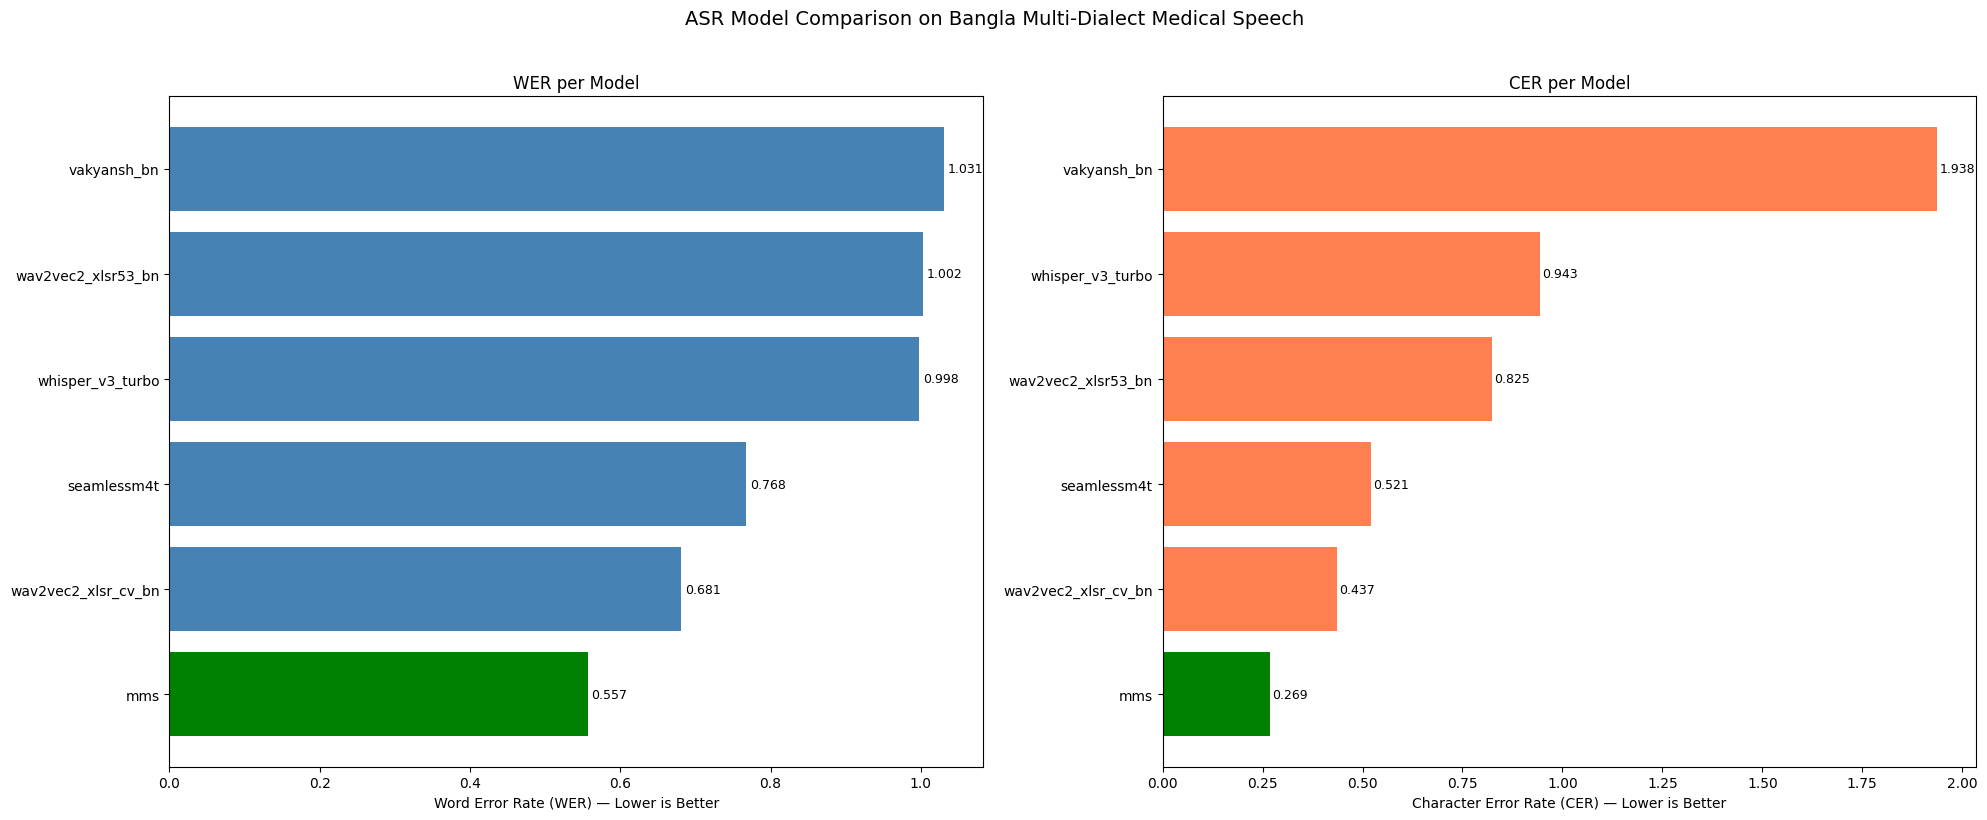

In [20]:
import matplotlib.pyplot as plt

# Compute average metrics per model from the DataFrame built above
avg_by_model = df.groupby('model')[['wer', 'cer', 'mer', 'wil', 'wip', 'bleu']].mean()

wer_data = avg_by_model['wer'].dropna().sort_values()
cer_data = avg_by_model['cer'].dropna().sort_values()

if len(wer_data) > 0 and len(cer_data) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # Left chart: WER
    colors_wer = ['green' if v == wer_data.min() else 'steelblue' for v in wer_data.values]
    ax1.barh(wer_data.index, wer_data.values, color=colors_wer)
    ax1.set_xlabel('Word Error Rate (WER) — Lower is Better')
    ax1.set_title('WER per Model')
    for i, (model, v) in enumerate(wer_data.items()):
        ax1.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

    # Right chart: CER
    colors_cer = ['green' if v == cer_data.min() else 'coral' for v in cer_data.values]
    ax2.barh(cer_data.index, cer_data.values, color=colors_cer)
    ax2.set_xlabel('Character Error Rate (CER) — Lower is Better')
    ax2.set_title('CER per Model')
    for i, (model, v) in enumerate(cer_data.items()):
        ax2.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

    fig.suptitle('ASR Model Comparison on Bangla Multi-Dialect Medical Speech', fontsize=14, y=1.02)
    plt.tight_layout()

    chart_path = f'{EVALUATION_DIR}/evaluation_charts.png'
    plt.savefig(chart_path, dpi=150, bbox_inches='tight')
    print(f'✅ Chart saved: {chart_path}')
    plt.show()
else:
    print('⚠️  No metric data to plot. Provide reference transcripts first.')


---
## Dialect-Level Accuracy + Rebuild dialect_accuracy.csv
Recreates the `dialect_accuracy.csv` that existed from your first run, now with real WER values.

In [21]:
# A transcript is 'correct' if WER < 0.3 (less than 30% word error)
WER_THRESHOLD = 0.3

dialect_rows = []
for model_name in df['model'].unique():
    model_df = df[df['model'] == model_name].copy()
    row = {'model': model_name}
    overall_correct = 0
    overall_total   = 0
    for dialect in DIALECT_FOLDERS:
        d_df = model_df[model_df['dialect'] == dialect]
        # Only count files where WER was calculable (reference exists)
        has_wer  = d_df['wer'].notna()
        correct  = (d_df.loc[has_wer, 'wer'] < WER_THRESHOLD).sum()
        total    = has_wer.sum()
        accuracy = round(correct / total, 3) if total > 0 else None
        row[dialect]       = accuracy
        row[f'{dialect}_correct'] = int(correct)
        row[f'{dialect}_total']   = int(total)
        overall_correct += correct
        overall_total   += total
    row['OVERALL'] = round(overall_correct / overall_total, 3) if overall_total > 0 else None
    dialect_rows.append(row)

dialect_df = pd.DataFrame(dialect_rows).set_index('model')

# Save — overwrites old empty dialect_accuracy.csv
dialect_acc_path = os.path.join(EVALUATION_DIR, 'dialect_accuracy.csv')
dialect_df.to_csv(dialect_acc_path)
print(f'✅ Saved: {dialect_acc_path}')

# Print clean view (just accuracy columns, no counts)
display_cols = DIALECT_FOLDERS + ['OVERALL']
print('\n=== Dialect-Level Soft Accuracy (WER < 0.3 = correct) ===')
print('(None = no reference transcripts for that dialect yet)')
print(dialect_df[display_cols].to_string())

✅ Saved: /content/drive/MyDrive/CSE499_EHR_Project/02_Phase1_ASR/evaluation/dialect_accuracy.csv

=== Dialect-Level Soft Accuracy (WER < 0.3 = correct) ===
(None = no reference transcripts for that dialect yet)
                    puran_dhaka  barishal sylheti  normal_bangla  indian_bangla  OVERALL
model                                                                                   
wav2vec2_xlsr53_bn         None       0.0    None          0.000          0.000    0.000
vakyansh_bn                None       0.0    None          0.000          0.000    0.000
wav2vec2_xlsr_cv_bn        None       0.0    None          0.163          0.082    0.113
whisper_small              None       NaN    None            NaN            NaN      NaN
whisper_medium             None       NaN    None            NaN            NaN      NaN
whisper_v3_turbo           None       0.0    None            NaN            NaN    0.000
mms                        None       0.0    None          0.122          0.1

---
## Dialect-Level Confusion Matrix
For each model, this builds a 5×5 matrix where each cell shows the count of test samples from a given true dialect that were classified as "correct" (WER < 0.3) or "incorrect" (WER ≥ 0.3). Also shows per-dialect WER heatmap.
Saved to `evaluation/confusion_matrices/`.


✅ wav2vec2_xlsr53_bn confusion matrix saved: /content/drive/MyDrive/CSE499_EHR_Project/02_Phase1_ASR/evaluation/confusion_matrices/wav2vec2_xlsr53_bn_confusion.png


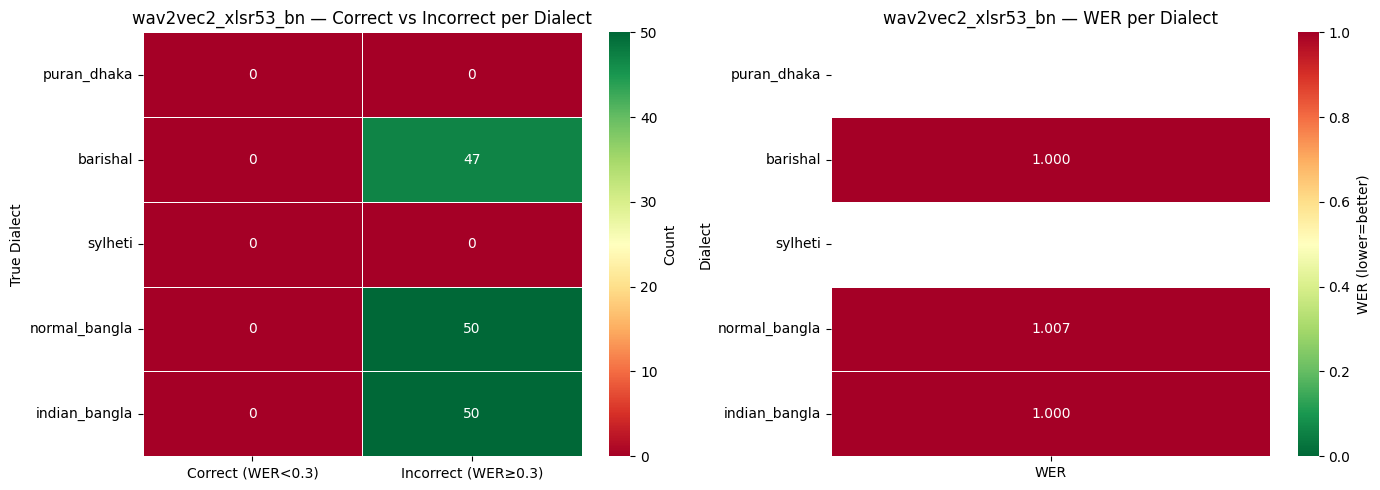

✅ vakyansh_bn confusion matrix saved: /content/drive/MyDrive/CSE499_EHR_Project/02_Phase1_ASR/evaluation/confusion_matrices/vakyansh_bn_confusion.png


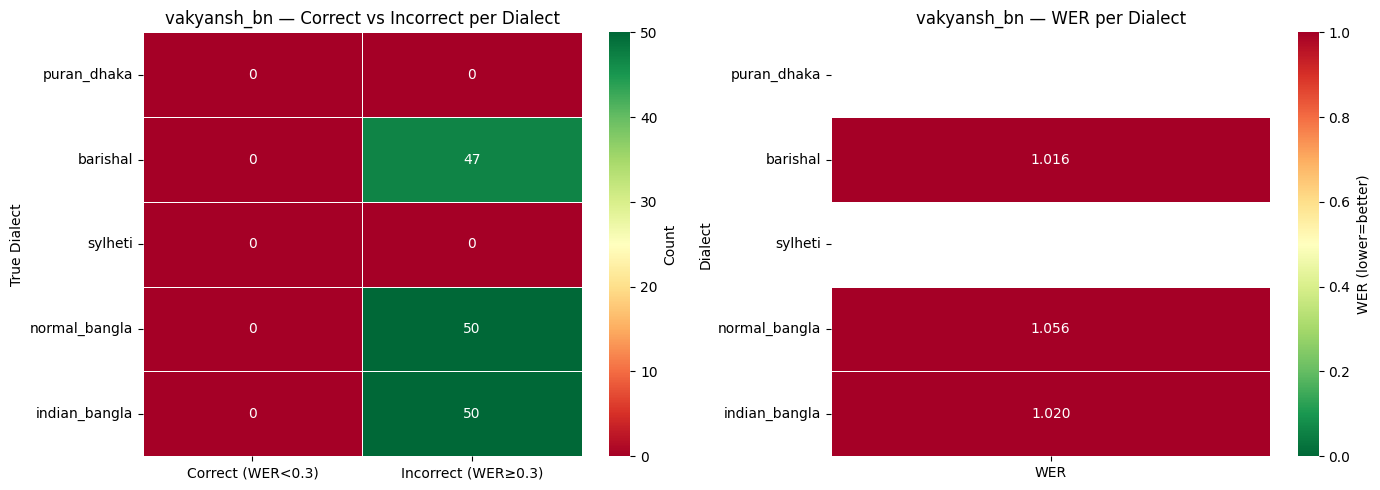

✅ wav2vec2_xlsr_cv_bn confusion matrix saved: /content/drive/MyDrive/CSE499_EHR_Project/02_Phase1_ASR/evaluation/confusion_matrices/wav2vec2_xlsr_cv_bn_confusion.png


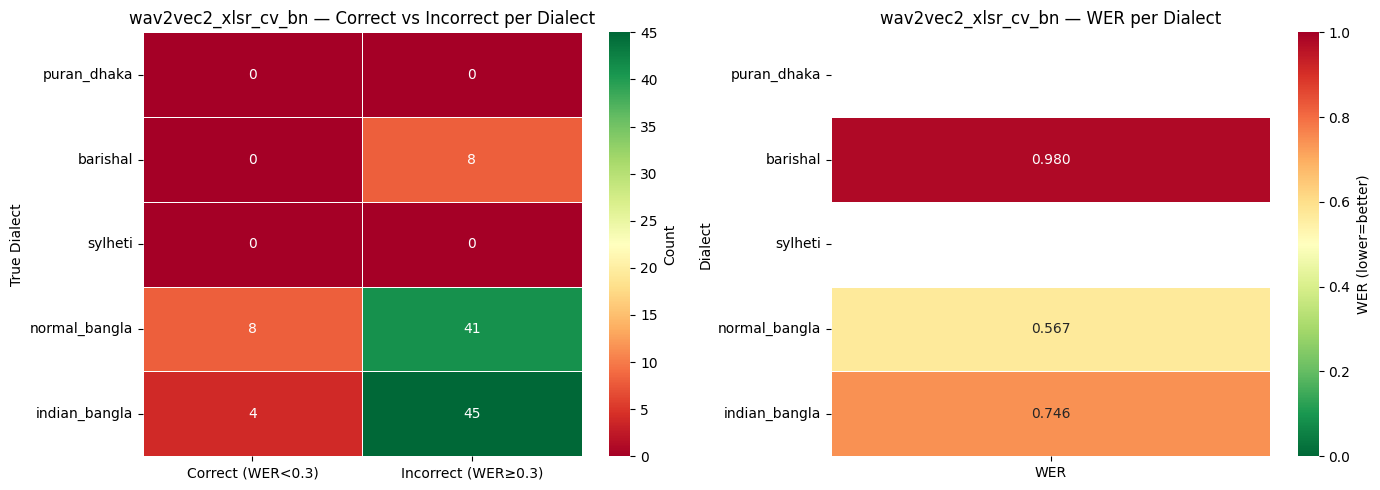

⏭️  whisper_small: No WER data — skipping confusion matrix.
⏭️  whisper_medium: No WER data — skipping confusion matrix.
✅ whisper_v3_turbo confusion matrix saved: /content/drive/MyDrive/CSE499_EHR_Project/02_Phase1_ASR/evaluation/confusion_matrices/whisper_v3_turbo_confusion.png


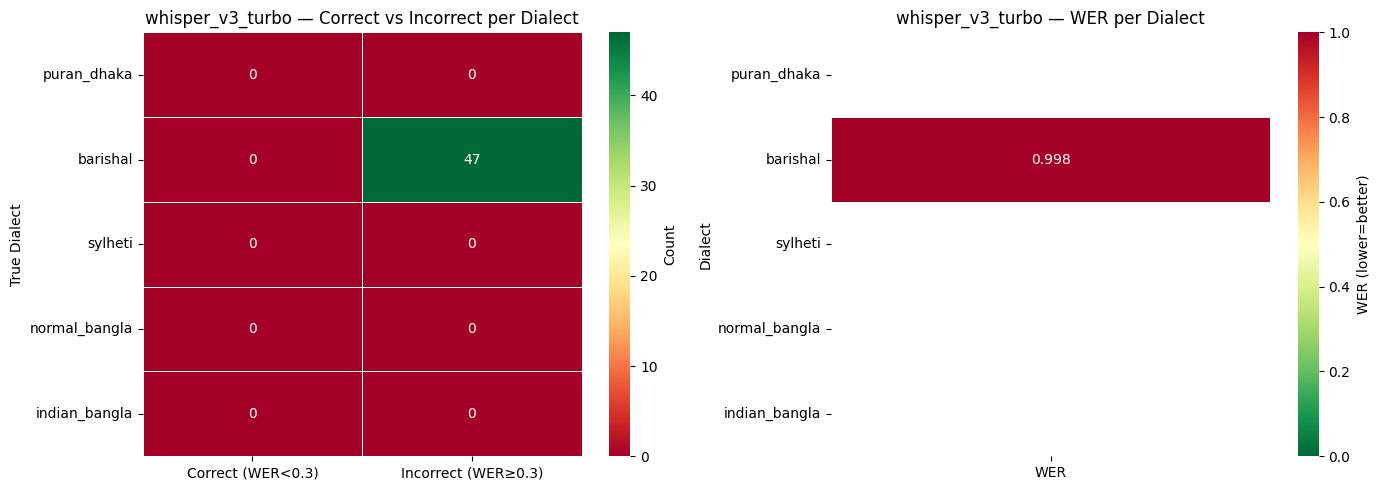

✅ mms confusion matrix saved: /content/drive/MyDrive/CSE499_EHR_Project/02_Phase1_ASR/evaluation/confusion_matrices/mms_confusion.png


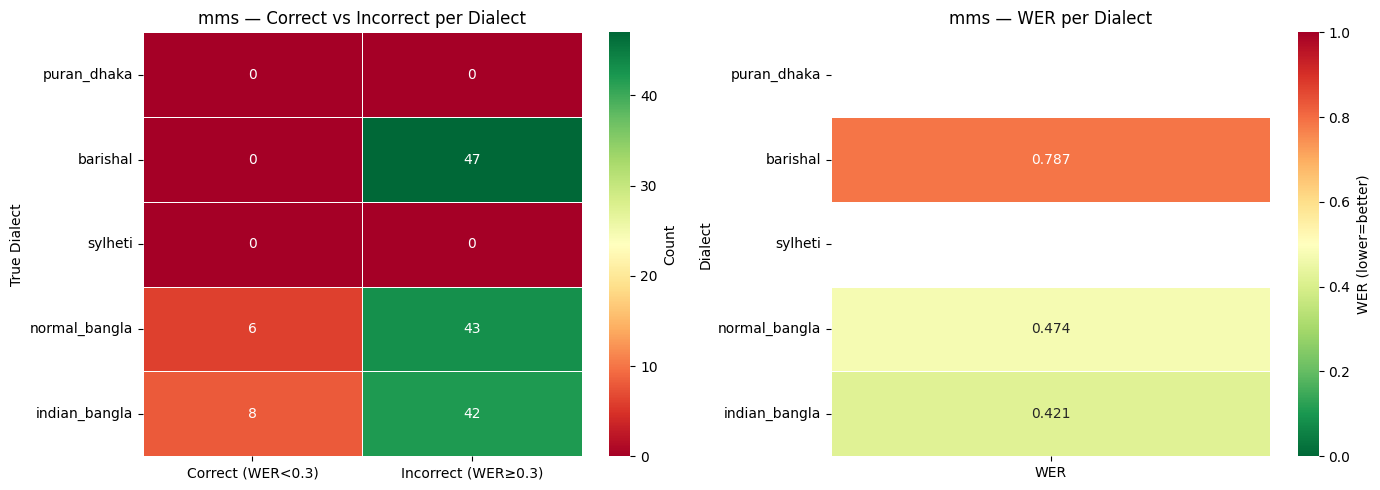

✅ seamlessm4t confusion matrix saved: /content/drive/MyDrive/CSE499_EHR_Project/02_Phase1_ASR/evaluation/confusion_matrices/seamlessm4t_confusion.png


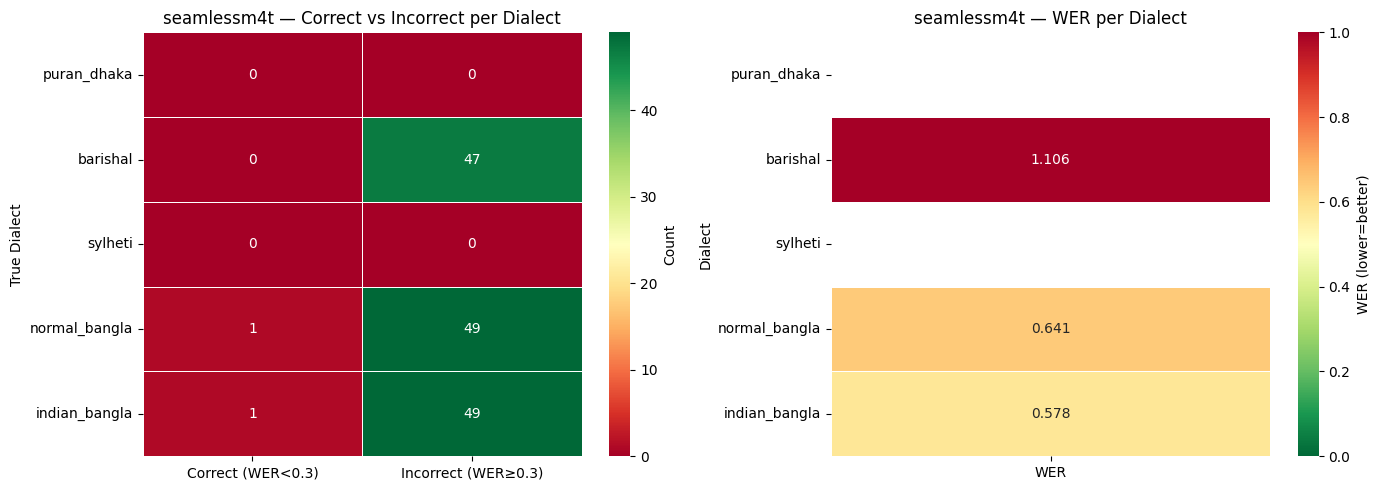

⏭️  whisper_large_v3: No WER data — skipping confusion matrix.

✅ All confusion matrices saved to: /content/drive/MyDrive/CSE499_EHR_Project/02_Phase1_ASR/evaluation/confusion_matrices/


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

SOFT_THRESHOLD = 0.3  # Ensure threshold is defined

os.makedirs(f'{EVALUATION_DIR}/confusion_matrices', exist_ok=True)

for model_name in df['model'].unique():
    model_df = df[df['model'] == model_name]

    # Skip models with no valid WER data
    valid = model_df[model_df['wer'].notna()]
    if len(valid) == 0:
        print(f'⏭️  {model_name}: No WER data — skipping confusion matrix.')
        continue

    # Build confusion-style data: for each dialect, count correct vs incorrect
    matrix_data = {}
    for dialect in DIALECT_FOLDERS:
        dialect_valid = valid[valid['dialect'] == dialect]
        correct   = (dialect_valid['wer'] < SOFT_THRESHOLD).sum()
        incorrect = len(dialect_valid) - correct
        matrix_data[dialect] = {'Correct (WER<0.3)': correct, 'Incorrect (WER≥0.3)': incorrect}

    matrix_df = pd.DataFrame(matrix_data).T
    matrix_df.index.name = 'Dialect'

    # Per-dialect WER/CER/BLEU breakdown
    dialect_metrics = {}
    for dialect in DIALECT_FOLDERS:
        d_valid = valid[valid['dialect'] == dialect]
        if len(d_valid) > 0:
            dialect_metrics[dialect] = {
                'WER':  d_valid['wer'].mean(),
                'CER':  d_valid['cer'].mean() if 'cer' in d_valid else None,
                'BLEU': d_valid['bleu'].mean() if 'bleu' in d_valid else None,
            }
        else:
            dialect_metrics[dialect] = {'WER': None, 'CER': None, 'BLEU': None}

    metrics_df = pd.DataFrame(dialect_metrics).T

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left: correct/incorrect counts
    sns.heatmap(matrix_df, annot=True, fmt='d', cmap='RdYlGn', ax=ax1,
                linewidths=0.5, cbar_kws={'label': 'Count'})
    ax1.set_title(f'{model_name} — Correct vs Incorrect per Dialect')
    ax1.set_ylabel('True Dialect')

    # Right: WER heatmap per dialect
    wer_matrix = metrics_df[['WER']].astype(float)
    sns.heatmap(wer_matrix, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax2,
                linewidths=0.5, cbar_kws={'label': 'WER (lower=better)'},
                vmin=0, vmax=1)
    ax2.set_title(f'{model_name} — WER per Dialect')
    ax2.set_ylabel('Dialect')

    plt.tight_layout()

    cm_path = f'{EVALUATION_DIR}/confusion_matrices/{model_name}_confusion.png'
    plt.savefig(cm_path, dpi=150, bbox_inches='tight')
    print(f'✅ {model_name} confusion matrix saved: {cm_path}')
    plt.show()

print(f'\n✅ All confusion matrices saved to: {EVALUATION_DIR}/confusion_matrices/')


---
## ⚠️ Reference Transcript Check


In [23]:
print('📋 Reference transcript check:')
print(f'   Expected folder: {MANUAL_TRANSCRIPTS_DIR}')
print()

total_found = 0
for dialect in DIALECT_FOLDERS:
    dialect_ref_dir = os.path.join(MANUAL_TRANSCRIPTS_DIR, dialect)
    if not os.path.exists(dialect_ref_dir):
        print(f'  ❌ {dialect}: folder does not exist → {dialect_ref_dir}')
        continue
    txt_files = [f for f in os.listdir(dialect_ref_dir) if f.endswith('.txt')]
    total_found += len(txt_files)
    print(f'  {"✅" if len(txt_files) > 0 else "⚠️ "} {dialect}: {len(txt_files)} reference .txt files found')

print(f'\n  Total references found: {total_found}')
if total_found == 0:
    print('  ❌ No references found at all. Check your folder path.')
    print(f'  Expected: {MANUAL_TRANSCRIPTS_DIR}/[dialect]/[audio_name].txt')
    print('  Example:  .../manual/barishal/br_001_male_25s_clip001.txt')
elif total_found < 250:
    print(f'  ⚠️  Only {total_found}/250 references found. WER will be None for missing ones.')
else:
    print(f'  ✅ All 250 reference files found. Full WER calculation possible.')

📋 Reference transcript check:
   Expected folder: /content/drive/MyDrive/CSE499_EHR_Project/01_Dataset/transcripts/manual

  ✅ puran_dhaka: 44 reference .txt files found
  ✅ barishal: 50 reference .txt files found
  ✅ sylheti: 50 reference .txt files found
  ✅ normal_bangla: 50 reference .txt files found
  ✅ indian_bangla: 50 reference .txt files found

  Total references found: 244
  ⚠️  Only 244/250 references found. WER will be None for missing ones.


---
## ✅ Complete (v2 — All 12 Models Fixed)

**What was updated in Google Drive:**

| File | Location | What changed |
|------|----------|--------------|
| `evaluation_scores.csv` | `02_Phase1_ASR/evaluation/` | Now has WER for ALL 12 models |
| `wer_scores.csv` | `02_Phase1_ASR/evaluation/` | Same data, duplicate for compatibility |
| `evaluation_charts.png` | `02_Phase1_ASR/evaluation/` | NEW — WER/CER bar charts |
| `dialect_accuracy.csv` | `02_Phase1_ASR/evaluation/` | Soft accuracy per dialect per model |
| `confusion_matrices/` | `02_Phase1_ASR/evaluation/` | NEW — per-model dialect confusion heatmaps |
| Transcript folders | `02_Phase1_ASR/model_outputs/` | All 12 models now have transcripts |

**Fixes applied in this version:**
1. `safe_load_wav2vec2` — snapshot_download + full tokenizer patching (arijitx model)
2. Whisper dtype — float32 for small/medium, float16 + input cast for large
3. `forced_decoder_ids` → `language`/`task` API (all Whisper + BengaliAI models)
4. SeamlessM4T — `audios=` → `audio=` (from v1)
